# SEED Experiments

### Dependencies

In [1]:
# Added for offline HF access
import os
# os.environ["TRANSFORMERS_OFFLINE"] = "1"
# os.environ["HF_DATASETS_OFFLINE"] = "1"

# # Disable Hugging Face Hub internet access
# os.environ["HF_HUB_OFFLINE"] = "1"
# os.environ["TRANSFORMERS_OFFLINE"] = "1"

import random

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import re
import math
import torch
import joblib
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch.nn as nn
# import yfinance as yf

import seaborn as sns
# from chronos import ChronosPipeline
from sklearn.metrics import *
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from transformers import AutoModel
from datetime import datetime, timedelta
import matplotlib as mpl
from matplotlib.patches import Patch
from transformers import get_cosine_schedule_with_warmup
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, DistilBertModel
from transformers import BertTokenizer, DistilBertTokenizer, BertTokenizerFast
from transformers import AutoTokenizer, AutoModelForMaskedLM
from transformers import BertModel

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
LOG_DIR = '/kaggle/working/logs'
os.makedirs(LOG_DIR, exist_ok=True)

# Data Merging and Exploration

In [6]:
# !git clone https://github.com/AdityaLab/Time-MMD.git
# !git clone https://github.com/AdityaLab/MM-TSFlib.git  

In [7]:
# numeric_df = pd.read_csv("/kaggle/working/Time-MMD/numerical/Health_US/Health_US.csv")
# numeric_df

In [8]:
# numeric_df.isnull().sum().sort_values()

In [9]:
# Time-MMD Dataset
# numeric_df.info()

- ### Health_report.csv:

This contains text from official sources like CDC weekly influenza surveillance reports (1999–present) and annual flu season studies/news (2019–present). Each row represents a textual entry (with columns like start_date, end_date, fact, pred) tied to a specific time interval (weekly in most cases). "Fact" is objective info (e.g., current statistics), and "pred" is predictions/insights (e.g., future trends).

- ### Health_search.csv:
This contains text from web search results generated weekly using keywords like "influenza" and "epidemic" (from general sources). It has the same column structure but from a different origin—more dynamic and potentially noisier, with broader coverage (e.g., news snippets).

In [10]:
# report_df = pd.read_csv("/kaggle/working/Time-MMD/textual/Health_US/Health_US_report.csv")
# search_df = pd.read_csv("/kaggle/working/Time-MMD/textual/Health_US/Health_US_search.csv")

In [11]:
# report_df.head(3)

In [12]:
# search_df.head(3)

In [13]:
# It is likely that we dont need the "end_date"
# search_df.drop(["Unnamed: 0"], axis=1, inplace=True)
# search_df.head(3)

In [14]:
# same for the report_df
# report_df.drop(["Unnamed: 0"], axis=1, inplace=True)
# report_df.head(3)

In [15]:
# text_df = pd.concat([report_df, search_df], ignore_index=True)
# text_df.head(3)

In [16]:
# print(f"report data size: {report_df.shape}")
# print(f"search data size: {search_df.shape}")
# print(f"merged data size: {text_df.shape}")

### New Data

In [17]:
# new cell
df = pd.read_csv("/kaggle/input/datasets/mohammadhossein77/ili-data/US_FLURATIO_Week.csv")
df.head(3)

,date,start_date,end_date,REGION TYPE,REGION,YEAR,WEEK,% WEIGHTED ILI,OT,AGE 0-4,...,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS,YEAR_WEEK,prior_history_avg,prior_history_std,Final_Search_2,Final_Search_4,Final_Search_6,Final_Output
0,9/29/1997,9/29/1997,10/5/1997,National,X,1997,40,1.10148,1.21686,179,...,570,192,46842,1997-40,0.0,0.0,Available facts are as follows: 1997-09-22: Za...,Available facts are as follows: 1997-09-22: Za...,Available facts are as follows: 1997-09-22: Za...,"Based on the provided textual information, I p..."
1,10/6/1997,10/6/1997,10/12/1997,National,X,1997,41,1.20007,1.28064,199,...,615,191,48023,1997-41,0.0,0.0,Available facts are as follows: 1997-09-29: Th...,Available facts are as follows: 1997-09-29: Th...,Available facts are as follows: 1997-09-29: Th...,"Based on the provided textual information, my ..."
2,10/13/1997,10/13/1997,10/19/1997,National,X,1997,42,1.37876,1.23906,228,...,681,219,54961,1997-42,0.0,0.0,Available facts are as follows: 1997-10-06: Th...,Available facts are as follows: 1997-10-06: Th...,Available facts are as follows: 1997-10-06: Th...,"Based on the available textual information, I ..."


In [18]:
# df["Final_Search_2"].iloc[1:2].values[0]

In [19]:
# df["Final_Search_4"].iloc[1:2].values[0]

In [20]:
# df["Final_Search_6"].iloc[1:2].values[0]

In [21]:
# df["Final_Output"].iloc[1:2].values[0]

In [22]:
# len(df["Final_Search_2"].iloc[1:2].values[0])

In [23]:
# len(df["Final_Search_4"].iloc[1:2].values[0])

In [24]:
# len(df["Final_Search_6"].iloc[1:2].values[0])

In [25]:
# len(df["Final_Search_6"].head(1)[0])

In [26]:
# we will only keep the finaL_search_2 
text_df = pd.DataFrame()
text_df["facts"] = df["Final_Search_6"]
text_df.head()

,facts
0,Available facts are as follows: 1997-09-22: Za...
1,Available facts are as follows: 1997-09-29: Th...
2,Available facts are as follows: 1997-10-06: Th...
3,Available facts are as follows: 1997-10-13: Ob...
4,Available facts are as follows: 1997-10-20: Th...


In [27]:
# df.columns

In [28]:
# df["Final_Output"].iloc[:1].values[0]

In [29]:
text_df["preds"] = df["Final_Output"]
text_df.head(3)

,facts,preds
0,Available facts are as follows: 1997-09-22: Za...,"Based on the provided textual information, I p..."
1,Available facts are as follows: 1997-09-29: Th...,"Based on the provided textual information, my ..."
2,Available facts are as follows: 1997-10-06: Th...,"Based on the available textual information, I ..."


In [30]:
text_df.shape

(1389, 2)

In [31]:
numeric_df = pd.DataFrame()
numeric_df = df.iloc[:, :-4]
numeric_df.head(3)

,date,start_date,end_date,REGION TYPE,REGION,YEAR,WEEK,% WEIGHTED ILI,OT,AGE 0-4,...,AGE 25-64,AGE 5-24,AGE 50-64,AGE 65,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS,YEAR_WEEK,prior_history_avg,prior_history_std
0,9/29/1997,9/29/1997,10/5/1997,National,X,1997,40,1.10148,1.21686,179,...,157,205,X,29,570,192,46842,1997-40,0.0,0.0
1,10/6/1997,10/6/1997,10/12/1997,National,X,1997,41,1.20007,1.28064,199,...,151,242,X,23,615,191,48023,1997-41,0.0,0.0
2,10/13/1997,10/13/1997,10/19/1997,National,X,1997,42,1.37876,1.23906,228,...,153,266,X,34,681,219,54961,1997-42,0.0,0.0


In [32]:
del df

In [33]:
numeric_df.drop(["date"], axis=1, inplace=True)
numeric_df['start_date'] = pd.to_datetime(numeric_df['start_date'])
numeric_df['end_date'] = pd.to_datetime(numeric_df['end_date'])
numeric_df.head(3)

,start_date,end_date,REGION TYPE,REGION,YEAR,WEEK,% WEIGHTED ILI,OT,AGE 0-4,AGE 25-49,AGE 25-64,AGE 5-24,AGE 50-64,AGE 65,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS,YEAR_WEEK,prior_history_avg,prior_history_std
0,1997-09-29,1997-10-05,National,X,1997,40,1.10148,1.21686,179,X,157,205,X,29,570,192,46842,1997-40,0.0,0.0
1,1997-10-06,1997-10-12,National,X,1997,41,1.20007,1.28064,199,X,151,242,X,23,615,191,48023,1997-41,0.0,0.0
2,1997-10-13,1997-10-19,National,X,1997,42,1.37876,1.23906,228,X,153,266,X,34,681,219,54961,1997-42,0.0,0.0


In [34]:
text_df.head(3)

,facts,preds
0,Available facts are as follows: 1997-09-22: Za...,"Based on the provided textual information, I p..."
1,Available facts are as follows: 1997-09-29: Th...,"Based on the provided textual information, my ..."
2,Available facts are as follows: 1997-10-06: Th...,"Based on the available textual information, I ..."


In [35]:
print(f"text_df shape: {text_df.shape}\nnumeric_df shape: {numeric_df.shape}")

text_df shape: (1389, 2)
numeric_df shape: (1389, 20)


In [36]:
merged_df = pd.concat([numeric_df, text_df], axis=1)
merged_df.head(3)

,start_date,end_date,REGION TYPE,REGION,YEAR,WEEK,% WEIGHTED ILI,OT,AGE 0-4,AGE 25-49,...,AGE 50-64,AGE 65,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS,YEAR_WEEK,prior_history_avg,prior_history_std,facts,preds
0,1997-09-29,1997-10-05,National,X,1997,40,1.10148,1.21686,179,X,...,X,29,570,192,46842,1997-40,0.0,0.0,Available facts are as follows: 1997-09-22: Za...,"Based on the provided textual information, I p..."
1,1997-10-06,1997-10-12,National,X,1997,41,1.20007,1.28064,199,X,...,X,23,615,191,48023,1997-41,0.0,0.0,Available facts are as follows: 1997-09-29: Th...,"Based on the provided textual information, my ..."
2,1997-10-13,1997-10-19,National,X,1997,42,1.37876,1.23906,228,X,...,X,34,681,219,54961,1997-42,0.0,0.0,Available facts are as follows: 1997-10-06: Th...,"Based on the available textual information, I ..."


In [37]:
merged_df.isnull().sum()

start_date            0
end_date              0
REGION TYPE           0
REGION                0
YEAR                  0
WEEK                  0
% WEIGHTED ILI        0
OT                    0
AGE 0-4               0
AGE 25-49             0
AGE 25-64             0
AGE 5-24              0
AGE 50-64             0
AGE 65                0
ILITOTAL              0
NUM. OF PROVIDERS     0
TOTAL PATIENTS        0
YEAR_WEEK             0
prior_history_avg     0
prior_history_std    53
facts                 0
preds                 0
dtype: int64

### CoT module

In [38]:
# import pandas as pd
# import requests
# import json
# from tqdm import tqdm
# import time


# # LM Studio server configuration (default settings)
# LM_STUDIO_URL = "http://localhost:1234/v1/chat/completions"


# def summarize_with_lmstudio(text, model_name="model_name"):
#     """
#     Summarize text using your local LM Studio model
#     Replace "your-model-name" with what you see in LM Studio
#     """
#     if pd.isna(text) or len(str(text).strip()) < 50:
#         return str(text)[:384]
    
#     # Limit input to avoid overwhelming the model
#     text = str(text)[:3500]
    
#     # The prompt - tailored for your influenza prediction task
#     prompt = f"""You are a text summarizer for a health prediction system.

# TASK: Summarize this influenza/flu news search report concisely but keep ALL key information that helps the model to predict influenza rate in future.

# WHAT TO KEEP:
# - Specific dates and their key events (e.g., "1997-09-22: Zanamivir treatment...")
# - Mortality rates, infection percentages, any numbers that is relevant
# - Outbreak locations and patterns
# - Treatments, vaccines, antivirals mentioned
# - Prevention strategies and surveillance info
# - At-risk populations (seniors, age groups, etc.)
# - Any temporal trends or changes over time

# WHAT TO REMOVE:
# - Source citations like "[Source: ...]"
# - Meta-statements like "Objective facts about..."
# - Redundant or repetitive information

# FORMAT: Keep date entries when present. Keep it under 380 words (so BERT can process it with max_len not more than 384).

# TEXT TO SUMMARIZE:
# {text}

# CONCISE SUMMARY WITH KEY PREDICTIVE INFORMATION:"""

#     # Prepare the API request (OpenAI-compatible format) [citation:8]
#     payload = {
#         "model": model_name,  # Replace with your actual model name
#         "messages": [
#             {"role": "user", "content": prompt}
#         ],
#         "temperature": 0.3,  # Lower = more focused, factual
#         "max_tokens": 500,   # Generates ~300-400 words
#         "top_p": 0.95
#     }
    
#     try:
#         response = requests.post(
#             LM_STUDIO_URL,
#             headers={"Content-Type": "application/json"},
#             json=payload,
#             timeout=60  # 60 seconds timeout
#         )
        
#         if response.status_code == 200:
#             result = response.json()
#             summary = result['choices'][0]['message']['content']
            
#             # Ensure under BERT's 384 token limit (~550 chars)
#             if len(summary) > 560:
#                 summary = summary[:560].rsplit(' ', 1)[0]
            
#             return summary
#         else:
#             print(f"API Error {response.status_code}: {response.text}")
#             return text[:384]  # Fallback to truncation
            
#     except requests.exceptions.Timeout:
#         print("Request timed out - model might be slow")
#         return text[:384]
#     except Exception as e:
#         print(f"Error: {e}")
#         return text[:384]




In [39]:
# # lets see ....
# df = merged_df
# model_name = "google/gemma-3-4b"  


# # Apply summarization to your text column
# print("\nSummarizing all rows...")
# tqdm.pandas(desc="Processing")
# df['summarized_text'] = df['facts'].progress_apply(
#     lambda x: summarize_with_lmstudio(x, model_name)
# )


# # Save the results
# output_file = "summarized_data.csv"
# df.to_csv(output_file, index=False)
# print(f"\nDone! Saved to {output_file}")

# # Check the results
# print("\nSummary Statistics:")
# print(f"Average summary length: {df['summarized_text'].str.len().mean():.0f} characters")
# print(f"Max summary length: {df['summarized_text'].str.len().max()} characters")

# # Show an example
# print("\nExample output (first row):")
# print("-" * 50)
# print(df.iloc[0]['summarized_text'][:500])
# print("-" * 50)

### End of the modifications made to the code

In [40]:
## Align on dates 
# numeric_df['start_date'] = pd.to_datetime(numeric_df['start_date'])  
# text_df['start_date'] = pd.to_datetime(text_df['start_date'])
# merged_df = pd.merge(numeric_df, text_df, on='start_date', how='left').fillna('')  # Fill missing text with empty

In [41]:
# lets drop the facts column. 
# Considering that the CMA module is going to calculate an attention between two modalities
# and the LLM already used the facts to generate preds, there seems to be no point in using 
# summarized facts as an input to the CMA. In fact, I suspect that it would introduce noise
# in text signal.

# merged_df.drop(["facts"], axis=1, inplace=True)

In [42]:
# merged_df[["AGE 25-49", # object
#            "AGE 50-64", # object
#            "AGE 25-64" # this one seeems to be the sum of the previous ones (object)
#           ]]

In [43]:
merged_df.isna().sum()

start_date            0
end_date              0
REGION TYPE           0
REGION                0
YEAR                  0
WEEK                  0
% WEIGHTED ILI        0
OT                    0
AGE 0-4               0
AGE 25-49             0
AGE 25-64             0
AGE 5-24              0
AGE 50-64             0
AGE 65                0
ILITOTAL              0
NUM. OF PROVIDERS     0
TOTAL PATIENTS        0
YEAR_WEEK             0
prior_history_avg     0
prior_history_std    53
facts                 0
preds                 0
dtype: int64

In [44]:
# Update ----- "Week" feature should be defined in a manner that reflects its cyclic nature
merged_df["WEEK_sin"] = np.sin(2 * np.pi * (merged_df["WEEK"]/52))
merged_df["WEEK_cos"] = np.cos(2 * np.pi * (merged_df["WEEK"]/52))

merged_df.drop(["WEEK"], axis=1, inplace=True)
merged_df.head(3)

,start_date,end_date,REGION TYPE,REGION,YEAR,% WEIGHTED ILI,OT,AGE 0-4,AGE 25-49,AGE 25-64,...,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS,YEAR_WEEK,prior_history_avg,prior_history_std,facts,preds,WEEK_sin,WEEK_cos
0,1997-09-29,1997-10-05,National,X,1997,1.10148,1.21686,179,X,157,...,570,192,46842,1997-40,0.0,0.0,Available facts are as follows: 1997-09-22: Za...,"Based on the provided textual information, I p...",-0.992709,0.120537
1,1997-10-06,1997-10-12,National,X,1997,1.20007,1.28064,199,X,151,...,615,191,48023,1997-41,0.0,0.0,Available facts are as follows: 1997-09-29: Th...,"Based on the provided textual information, my ...",-0.970942,0.239316
2,1997-10-13,1997-10-19,National,X,1997,1.37876,1.23906,228,X,153,...,681,219,54961,1997-42,0.0,0.0,Available facts are as follows: 1997-10-06: Th...,"Based on the available textual information, I ...",-0.935016,0.354605


In [45]:
# # New cyclic features ....
# def add_trend_features(df):
#     df = df.copy()
#     # 1. Week-over-week change
#     # df["OT_diff_1"] = df["OT"].diff() # positive -> outbreak increasing (Vice-Versa)
    
#     # 2. Rooling average of OT rate
#     # df["OT_roll_mean_3"] = df["OT"].rolling(window=3).mean()
#     df["OT_roll_mean_9"] = df["OT"].rolling(window=9).mean()
    
#     # 3. Rooling standard deviation of OT rate
#     # df["OT_roll_std_3"] = df["OT"].rolling(window=3).std()
#     df["OT_roll_std_9"] = df["OT"].rolling(window=9).std()
    
#     # 4. Momentun rate
#     # df["OT_momentum_3"] = df["OT"] - df["OT"].shift(3)
#     # df["OT_momentum_6"] = df["OT"] - df["OT"].shift(6)

#     # 5. Relative Surge Feature
#     # df["OT_relative_6"] = (df["OT"] / df["OT_roll_mean_6"] + 1e-6) ## to not introduce new feature, I decided to rewrite it
#     # df["OT_relative_6"] = (df["OT"] / (df["OT"].rooling(window=6).mean() + 1e-6)) 

#     # 6. Acceleration feature
#     # df["OT_acceleration"] = df["OT_diff_1"].diff(1) 
#     df = df.fillna(0)

#     return df



In [46]:
merged_df["REGION TYPE"].value_counts()

REGION TYPE
National    1389
Name: count, dtype: int64

In [47]:
merged_df["REGION"].value_counts()

REGION
X    1389
Name: count, dtype: int64

In [48]:
merged_df["YEAR_WEEK"].value_counts()

YEAR_WEEK
2024-19    1
1997-40    1
1997-41    1
1997-42    1
1997-43    1
          ..
1998-3     1
1998-4     1
1998-5     1
1998-6     1
1998-7     1
Name: count, Length: 1389, dtype: int64

In [49]:
merged_df.drop(["REGION TYPE", "REGION", "YEAR_WEEK"], axis=1, inplace=True)

In [50]:
merged_df.columns

Index(['start_date', 'end_date', 'YEAR', '% WEIGHTED ILI', 'OT', 'AGE 0-4',
       'AGE 25-49', 'AGE 25-64', 'AGE 5-24', 'AGE 50-64', 'AGE 65', 'ILITOTAL',
       'NUM. OF PROVIDERS', 'TOTAL PATIENTS', 'prior_history_avg',
       'prior_history_std', 'facts', 'preds', 'WEEK_sin', 'WEEK_cos'],
      dtype='object')

In [51]:
merged_df.isna().sum()

start_date            0
end_date              0
YEAR                  0
% WEIGHTED ILI        0
OT                    0
AGE 0-4               0
AGE 25-49             0
AGE 25-64             0
AGE 5-24              0
AGE 50-64             0
AGE 65                0
ILITOTAL              0
NUM. OF PROVIDERS     0
TOTAL PATIENTS        0
prior_history_avg     0
prior_history_std    53
facts                 0
preds                 0
WEEK_sin              0
WEEK_cos              0
dtype: int64

In [52]:
merged_df.drop(["prior_history_std", "prior_history_avg"], axis=1, inplace=True)
merged_df.isna().sum()

start_date           0
end_date             0
YEAR                 0
% WEIGHTED ILI       0
OT                   0
AGE 0-4              0
AGE 25-49            0
AGE 25-64            0
AGE 5-24             0
AGE 50-64            0
AGE 65               0
ILITOTAL             0
NUM. OF PROVIDERS    0
TOTAL PATIENTS       0
facts                0
preds                0
WEEK_sin             0
WEEK_cos             0
dtype: int64

In [53]:
cols = merged_df.columns
cols

Index(['start_date', 'end_date', 'YEAR', '% WEIGHTED ILI', 'OT', 'AGE 0-4',
       'AGE 25-49', 'AGE 25-64', 'AGE 5-24', 'AGE 50-64', 'AGE 65', 'ILITOTAL',
       'NUM. OF PROVIDERS', 'TOTAL PATIENTS', 'facts', 'preds', 'WEEK_sin',
       'WEEK_cos'],
      dtype='object')

In [54]:
# Updated ----------------------
# start_date, end_date, REGTION_TYPE
num_features = ['YEAR',
                "WEEK_sin",
                "WEEK_cos",
                '% WEIGHTED ILI',
                'AGE 0-4',
                'AGE 5-24',
                'AGE 25-49',
                'AGE 25-64',
                'AGE 50-64',
                'AGE 65',
                'ILITOTAL',
                'NUM. OF PROVIDERS',
                'TOTAL PATIENTS'
               ]

print(f"Number of features: {len(num_features)}") # should be 13
print(num_features)


Number of features: 13
['YEAR', 'WEEK_sin', 'WEEK_cos', '% WEIGHTED ILI', 'AGE 0-4', 'AGE 5-24', 'AGE 25-49', 'AGE 25-64', 'AGE 50-64', 'AGE 65', 'ILITOTAL', 'NUM. OF PROVIDERS', 'TOTAL PATIENTS']


In [55]:
merged_df.isna().sum()

start_date           0
end_date             0
YEAR                 0
% WEIGHTED ILI       0
OT                   0
AGE 0-4              0
AGE 25-49            0
AGE 25-64            0
AGE 5-24             0
AGE 50-64            0
AGE 65               0
ILITOTAL             0
NUM. OF PROVIDERS    0
TOTAL PATIENTS       0
facts                0
preds                0
WEEK_sin             0
WEEK_cos             0
dtype: int64

In [56]:
# age_cols = ['AGE 25-49', 'AGE 50-64', 'AGE 25-64'] 
# now do the below code for all columns, not just those columns mentioned above
cols = merged_df.columns
merged_df[cols] = merged_df[cols].replace('X', np.nan) # for all columns
print(merged_df[cols].isna().sum())

start_date             0
end_date               0
YEAR                   0
% WEIGHTED ILI         0
OT                     0
AGE 0-4                0
AGE 25-49            532
AGE 25-64            762
AGE 5-24               0
AGE 50-64            532
AGE 65                 0
ILITOTAL               0
NUM. OF PROVIDERS      0
TOTAL PATIENTS         0
facts                  0
preds                  0
WEEK_sin               0
WEEK_cos               0
dtype: int64


In [57]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1389 entries, 0 to 1388
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   start_date         1389 non-null   datetime64[ns]
 1   end_date           1389 non-null   datetime64[ns]
 2   YEAR               1389 non-null   int64         
 3   % WEIGHTED ILI     1389 non-null   float64       
 4   OT                 1389 non-null   float64       
 5   AGE 0-4            1389 non-null   int64         
 6   AGE 25-49          857 non-null    object        
 7   AGE 25-64          627 non-null    object        
 8   AGE 5-24           1389 non-null   int64         
 9   AGE 50-64          857 non-null    object        
 10  AGE 65             1389 non-null   int64         
 11  ILITOTAL           1389 non-null   int64         
 12  NUM. OF PROVIDERS  1389 non-null   int64         
 13  TOTAL PATIENTS     1389 non-null   int64         
 14  facts   

In [58]:
merged_df[num_features] = merged_df[num_features].apply(pd.to_numeric, errors='coerce') # just the numeric ones
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1389 entries, 0 to 1388
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   start_date         1389 non-null   datetime64[ns]
 1   end_date           1389 non-null   datetime64[ns]
 2   YEAR               1389 non-null   int64         
 3   % WEIGHTED ILI     1389 non-null   float64       
 4   OT                 1389 non-null   float64       
 5   AGE 0-4            1389 non-null   int64         
 6   AGE 25-49          857 non-null    float64       
 7   AGE 25-64          627 non-null    float64       
 8   AGE 5-24           1389 non-null   int64         
 9   AGE 50-64          857 non-null    float64       
 10  AGE 65             1389 non-null   int64         
 11  ILITOTAL           1389 non-null   int64         
 12  NUM. OF PROVIDERS  1389 non-null   int64         
 13  TOTAL PATIENTS     1389 non-null   int64         
 14  facts   

# Data Preprocessing

In [59]:
merged_df.sort_values('start_date', inplace=True)

In [60]:
# Chronological split: 80% train, 10% val, 10% test
train_size = int(len(merged_df) * 0.8)
val_size = int(len(merged_df) * 0.1)

train_df = merged_df.iloc[:train_size].copy()
val_df   = merged_df.iloc[train_size:train_size + val_size].copy()
test_df  = merged_df.iloc[train_size + val_size:].copy()

print(f'Train: {len(train_df)*100/len(merged_df)}\nVal: {len(val_df)*100/len(merged_df)}\nTest: {len(test_df)*100/len(merged_df)}')

Train: 79.98560115190784
Val: 9.935205183585314
Test: 10.079193664506839


In [61]:
# Same Logic as before, but on scale of data frames
for df in [train_df, val_df, test_df]:
    mask_split_nan = df['AGE 25-49'].isna() & df['AGE 50-64'].isna() & ~df['AGE 25-64'].isna()
    df.loc[mask_split_nan, 'AGE 25-49'] = df.loc[mask_split_nan, 'AGE 25-64'] * 0.6
    df.loc[mask_split_nan, 'AGE 50-64'] = df.loc[mask_split_nan, 'AGE 25-64'] * 0.4
    
    mask_combined_nan = ~df['AGE 25-49'].isna() & ~df['AGE 50-64'].isna() & df['AGE 25-64'].isna()
    df.loc[mask_combined_nan, 'AGE 25-64'] = df.loc[mask_combined_nan, 'AGE 25-49'] + df.loc[mask_combined_nan, 'AGE 50-64']

In [62]:
print(merged_df.isna().sum())

start_date             0
end_date               0
YEAR                   0
% WEIGHTED ILI         0
OT                     0
AGE 0-4                0
AGE 25-49            532
AGE 25-64            762
AGE 5-24               0
AGE 50-64            532
AGE 65                 0
ILITOTAL               0
NUM. OF PROVIDERS      0
TOTAL PATIENTS         0
facts                  0
preds                  0
WEEK_sin               0
WEEK_cos               0
dtype: int64


In [63]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1389 entries, 0 to 1388
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   start_date         1389 non-null   datetime64[ns]
 1   end_date           1389 non-null   datetime64[ns]
 2   YEAR               1389 non-null   int64         
 3   % WEIGHTED ILI     1389 non-null   float64       
 4   OT                 1389 non-null   float64       
 5   AGE 0-4            1389 non-null   int64         
 6   AGE 25-49          857 non-null    float64       
 7   AGE 25-64          627 non-null    float64       
 8   AGE 5-24           1389 non-null   int64         
 9   AGE 50-64          857 non-null    float64       
 10  AGE 65             1389 non-null   int64         
 11  ILITOTAL           1389 non-null   int64         
 12  NUM. OF PROVIDERS  1389 non-null   int64         
 13  TOTAL PATIENTS     1389 non-null   int64         
 14  facts   

In [64]:
num_features

['YEAR',
 'WEEK_sin',
 'WEEK_cos',
 '% WEIGHTED ILI',
 'AGE 0-4',
 'AGE 5-24',
 'AGE 25-49',
 'AGE 25-64',
 'AGE 50-64',
 'AGE 65',
 'ILITOTAL',
 'NUM. OF PROVIDERS',
 'TOTAL PATIENTS']

In [65]:
scaler = MinMaxScaler()
train_df[num_features] = scaler.fit_transform(train_df[num_features])
val_df[num_features] = scaler.transform(val_df[num_features])
test_df[num_features] = scaler.transform(test_df[num_features])

# Saved for later (inverse transform predictions)
joblib.dump(scaler, f'{LOG_DIR}/feature_scaler.pkl')


# scaling targets (Updated to prevent leakage)
target_scaler = MinMaxScaler()
train_df["OT"] = target_scaler.fit_transform(train_df["OT"].values.reshape(-1,1)).flatten()
val_df["OT"] = target_scaler.transform(val_df["OT"].values.reshape(-1,1)).flatten()
test_df["OT"] = target_scaler.transform(test_df["OT"].values.reshape(-1,1)).flatten()

joblib.dump(target_scaler, f'{LOG_DIR}/target_scaler.pkl')

# Updated
# num_features.append("OT")

if "OT" not in num_features:
    num_features.append("OT")

In [66]:
# # Update -------------------------
# train_df = add_trend_features(train_df)
# val_df = add_trend_features(val_df)
# test_df = add_trend_features(test_df)

In [67]:
print(f"numerical features:\n{num_features}")

numerical features:
['YEAR', 'WEEK_sin', 'WEEK_cos', '% WEIGHTED ILI', 'AGE 0-4', 'AGE 5-24', 'AGE 25-49', 'AGE 25-64', 'AGE 50-64', 'AGE 65', 'ILITOTAL', 'NUM. OF PROVIDERS', 'TOTAL PATIENTS', 'OT']


In [68]:
print(f"columns:{merged_df.columns}\nshape:{merged_df.shape}")

columns:Index(['start_date', 'end_date', 'YEAR', '% WEIGHTED ILI', 'OT', 'AGE 0-4',
       'AGE 25-49', 'AGE 25-64', 'AGE 5-24', 'AGE 50-64', 'AGE 65', 'ILITOTAL',
       'NUM. OF PROVIDERS', 'TOTAL PATIENTS', 'facts', 'preds', 'WEEK_sin',
       'WEEK_cos'],
      dtype='object')
shape:(1389, 18)


In [69]:
# Same functionality as before but with Horizon & Look Back

def create_sequences(df, lookback, horizon):
    df = df.sort_values('start_date').reset_index(drop=True)  # Ensure order
    X_num, X_text, y=[], [], []
        
    for i in range(len(df) - lookback - horizon + 1):
        # 1. get the numerical features
        num_seq = df[num_features].iloc[i:i+lookback].values # (36,14)
        
        # 2. textuals too
        # Updated: Changing the texual contents into a list of values
        # text_seq = (df['facts'].iloc[i:i+lookback] + ' ' + df['preds'].iloc[i:i+lookback]).to_list()  # update: we no longer need the facts
        # text_seq = (df['preds'].iloc[i:i+lookback] + ' ' + df['facts'].iloc[i:i+lookback]).to_list() # to make sure facts survives the textual stream
        # text_seq = (df['preds'].iloc[i:i+lookback]).to_list()
        text_seq = (df['facts'].iloc[i:i+lookback]).to_list()
        
        # 3. and the OT (target)
        target = df['OT'].iloc[i+lookback:i+lookback+horizon].values # (12,)

        X_num.append(num_seq)
        X_text.append(text_seq)
        y.append(target)
        
    return np.array(X_num), np.array(X_text), np.array(y)
        

In [70]:
# Train / Val / Test splitting
lookback = 36 # Default of Time-MMD
horizon = 12  # predict 12 weeks at once

# X_num_train, X_text_train, y_train = create_sequences(train_df, lookback, horizon)
# X_num_val, X_text_val, y_val = create_sequences(val_df, lookback, horizon)
# X_num_test, X_text_test, y_test = create_sequences(test_df, lookback, horizon)

# Update --------
# Prepend the tail of the previous split so the first sequence 
# in val/test has a full 36-week lookback drawn from real history
val_df_full = pd.concat([train_df.iloc[-lookback:], val_df],  ignore_index=True)
test_df_full = pd.concat([val_df.iloc[-lookback:],  test_df], ignore_index=True)

X_num_train, X_text_train, y_train = create_sequences(train_df, lookback, horizon)
X_num_val, X_text_val, y_val = create_sequences(val_df_full, lookback, horizon)
X_num_test, X_text_test, y_test = create_sequences(test_df_full, lookback, horizon)

In [71]:
# Double checking
X_num_train.shape

(1064, 36, 14)

In [72]:
X_text_train.shape

(1064, 36)

In [73]:
# Double checking
y_train.shape

(1064, 12)

In [74]:

def tokenize_headlines(sequences, max_len=256, tokenizer=None): 
    """Added the functionality to handle various tokenizers and also made the caching mechanism faster"""
    if tokenizer is None:
        tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')  
    
    tokenized = []
    for sample in tqdm(sequences): 
        sample = sample.tolist()
        # sample: list of 36 weeks       
        enc = tokenizer(
            sample,                      # batch of 36 strings
            max_length = max_len,
            padding = 'max_length',
            truncation = True,
            return_tensors = 'pt'
            )

        tokenized.append({
            'input_ids': enc['input_ids'],
            'attention_mask': enc['attention_mask']
        })
        
    return tokenized 
  

## Dataset Creation

In [75]:
X_text_train.shape

(1064, 36)

In [76]:
# # UPDATED: Tokenize all the train, validation, and test sets once
# path = r"/home/user/GPU_enabled/Time-MMD/HF/hub/models--microsoft--BiomedNLP-PubMedBERT-base-uncased-abstract/snapshots/d673b8835373c6fa116d6d8006b33d48734e305d/"

# tokenizer = AutoTokenizer.from_pretrained(path, local_files_only=True)

In [77]:
X_text_train_tokenized = tokenize_headlines(X_text_train, 
                                            # tokenizer=DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
                                            # tokenizer = tokenizer,
                                            # tokenizer = AutoTokenizer.from_pretrained("microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext")
                                            tokenizer = AutoTokenizer.from_pretrained("michiyasunaga/BioLinkBERT-base")
                                           )

X_text_val_tokenized = tokenize_headlines(X_text_val, 
                                          # tokenizer=DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
                                          # tokenizer = tokenizer
                                          # tokenizer = AutoTokenizer.from_pretrained("microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext")
                                          tokenizer = AutoTokenizer.from_pretrained("michiyasunaga/BioLinkBERT-base")
                                         )

X_text_test_tokenized = tokenize_headlines(X_text_test, 
                                           # tokenizer=DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
                                           # tokenizer = tokenizer
                                           # tokenizer = AutoTokenizer.from_pretrained("microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext")
                                           tokenizer = AutoTokenizer.from_pretrained("michiyasunaga/BioLinkBERT-base")
                                          )

config.json:   0%|          | 0.00/559 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/379 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

100%|██████████| 129/129 [00:06<00:00, 21.32it/s]


In [78]:
class CustomDataset(Dataset):
    """Modified to have a 3D shape output"""
    def __init__(self, numerical_data, tokenized_text_data, targets):
        self.numerical_data = torch.tensor(numerical_data, dtype=torch.float32)          
        self.tokenized_text_data = tokenized_text_data  # List of dicts
        self.targets = torch.tensor(targets, dtype=torch.float32) 


    def __len__(self):
        return len(self.numerical_data)


    def __getitem__(self, idx):
        num = self.numerical_data[idx]  # (36, 14)
        text_input = self.tokenized_text_data[idx]  # Dict: (36, max_len)
        target = self.targets[idx]  # (12,)
        return num, text_input, target



In [79]:
train_dataset = CustomDataset(X_num_train, 
                              X_text_train_tokenized, 
                              y_train)

val_dataset = CustomDataset(X_num_val, 
                            X_text_val_tokenized, 
                            y_val)

test_dataset = CustomDataset(X_num_test, 
                             X_text_test_tokenized,
                             y_test)

In [80]:
batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)  
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [81]:
# train_dataset[0][1]['input_ids'].shape

# Neural Network Components

## Headline Encoder

In [82]:
class HeadlineEncoder(nn.Module):
    """
    Encodes multiple daily headlines into compact representations using BERT embeddings 
    and inter-headline Attention (sequence-friendly, robust to padding/missing headlines).
    """

    def __init__(self, 
                 freeze_bert=True, 
                 hidden_dim=256, 
                 num_heads=8, 
                 dropout=0.15): 
        super(HeadlineEncoder, self).__init__()
        
        
        # self.bert = AutoModel.from_pretrained("microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext")
        self.bert = AutoModel.from_pretrained("michiyasunaga/BioLinkBERT-base")
                                              # force_download=False,
                                              # resume_download=True
                                             # )
        
        self.freeze_bert = freeze_bert 
        # Always freeze everything first (Update --------------------)
        for param in self.bert.parameters():
            param.requires_grad = False
        
        # Then selectively unfreeze if requested
        if not freeze_bert:
            for param in self.bert.encoder.layer[-8:].parameters():
                param.requires_grad = True
            
        # Multi-head Attention across headlines
        self.headline_attention = nn.MultiheadAttention(
            embed_dim=768,   # BERT hidden size
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
            bias=False
        )

        # Transformer-style post-attention refinements
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(768)

        # Project to desired hidden dimension
        self.projection = nn.Linear(768, hidden_dim)


    
    def forward(self, input_ids, attention_masks):
        """
        This function implements self attention between weeks' texts.
        --------------------------------------------------------------------------------
        input_ids: (B, T, L)
            B = batch size, T = timesteps (weeks), L = tokens per week
        attention_masks: (B, T, L)
        Returns:
            output: (B, T, hidden_dim)
            attention_weights: (B, num_heads, T, T) [week-to-week attention maps]
        """

        B, T, L = input_ids.shape

        # Flatten to feed through BERT -> (B*T, L)
        flat_input_ids = input_ids.view(-1, L)
        flat_att_masks = attention_masks.view(-1, L)

        if self.freeze_bert:
            with torch.no_grad():
                bert_outputs = self.bert(input_ids=flat_input_ids, attention_mask=flat_att_masks)
        else:
            bert_outputs = self.bert(input_ids=flat_input_ids, attention_mask=flat_att_masks)

        
        # CLS token as headline embedding -> (B*T, 768)
        
        # week_embeds = bert_outputs.last_hidden_state[:, 0, :] # Updated --------- (not just CLS token anymore)
        last_hidden  = bert_outputs.last_hidden_state # (B*T, L, 768)
        token_mask = flat_att_masks.unsqueeze(-1) # (B*T, L, 1)
        week_embeds = (last_hidden * token_mask).sum(dim=1) / (token_mask.sum(dim =1).clamp(min=1e-6)) # (B*T, 768)
        
        
        # Reshape back -> (B, T, 768)
        week_embeds = week_embeds.view(B, T, 768)

        # Prepare mask: headlines that are non-empty
        week_mask = (input_ids.sum(dim=-1) > 0)  # (B, T)

        # Self-attention across weeks
        attended, attn_weights = self.headline_attention(
            query=week_embeds,
            key=week_embeds,
            value=week_embeds,
            key_padding_mask=(week_mask == 0),  # ignore empty headlines
            need_weights=True
            )

        # Residual + norm + dropout
        attended = self.layer_norm(attended + week_embeds)
        attended = self.dropout(attended)

        # Mask headlines (remove padded ones)
        week_mask_float = week_mask.unsqueeze(-1).float()
        masked = attended * week_mask_float

        # Project to hidden_dim
        projected = self.projection(masked) # UPDATED

        return projected, attn_weights


## Numerical Encoder

In [83]:
class NumericalEncoder(nn.Module):
    """Removed Chronos and replaced it with simple Transformer Encoder (Used to be BiLSTM)"""
    def __init__(self, 
                 input_dim=16, # Uddated
                 hidden_dim=256,
                 num_layers = 4,
                 dropout=0.15):
        super(NumericalEncoder, self).__init__()     
        
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model = hidden_dim,
            nhead=8,
            dropout=dropout,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers = num_layers
        )

        self.layer_norm = nn.LayerNorm(hidden_dim)
        
    
    def forward(self, x):

        x = self.input_proj(x)
        x = self.encoder(x)
        out = self.layer_norm(x)
      
        return out

## Cross Modal Attention Layer

In [84]:
class CrossModalAttention(nn.Module):
    """
    Double-sided cross-modal attention between numerical and headline encodings
    
    Two Questions are answered here: 
    - 1: Given the price patterns, how should I interpret the news? 
    - 2: Given the news sentiment, how should I interpret the price patterns?
    
    -------------------------------------------------------------------------
    Inputs:
        numerical_embs: (B, T, D)  -> weekly numerical features embeddings
        headline_embs:  (B, T, D)  -> weekly news embeddings
    Output:
        fused: (B, T, D)
    """

    # as before
    def __init__(self,
                 num_dim=1024,
                 text_dim = 768,
                 fused_dim = 1024,
                 num_heads=8,
                 dropout=0.15,
                 T=36 ,
                 return_attention = False
                ):
        super(CrossModalAttention, self).__init__()
        self.T = T
        self.fused_dim = fused_dim if fused_dim is not None else num_dim + text_dim

        # # as before
        # self.pos_num = nn.Embedding(T, num_dim)
        self.pos_text = nn.Embedding(T, text_dim)
        self.proj_num = nn.Linear(num_dim, self.fused_dim)
        self.proj_text = nn.Linear(text_dim, self.fused_dim)

        # Updated -------------------------
        self.num_norm = nn.LayerNorm(self.fused_dim)
        self.text_norm = nn.LayerNorm(self.fused_dim)

        # as before
        self.num_to_head = nn.MultiheadAttention(
            embed_dim=self.fused_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        
        self.head_to_num = nn.MultiheadAttention(
            embed_dim=self.fused_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        # as before  
        self.fc = nn.Linear(self.fused_dim * 2, self.fused_dim)
        self.layer_norm = nn.LayerNorm(self.fused_dim)
        self.dropout = nn.Dropout(dropout)



    
    def forward(self, numerical_embs, headline_embs, return_attention=False):
        """
        numerical_embs: (B, T, D)
        headline_embs:  (B, T, D)
        """

        # UPGRADE: we need the batch size
        B, T, _ = numerical_embs.shape
        
         
        # numerical_embs += self.pos_num(torch.arange(self.T, device=numerical_embs.device)).unsqueeze(0)
        # numerical_embs = numerical_embs + self.pos_num(torch.arange(self.T, device=numerical_embs.device)).unsqueeze(0)
        # headline_embs += self.pos_text(torch.arange(self.T, device=headline_embs.device)).unsqueeze(0)
        headline_embs = headline_embs + self.pos_text(torch.arange(self.T, device=headline_embs.device)).unsqueeze(0)
        
        numerical_embs = self.proj_num(numerical_embs)
        headline_embs = self.proj_text(headline_embs)

        # Update -----------------------------------------
        numerical_embs = self.num_norm(numerical_embs)
        headline_embs = self.text_norm(headline_embs)
        
        # as before
        num2head, _ = self.num_to_head(
            query=numerical_embs,
            key=headline_embs,
            value=headline_embs,
            need_weights=False 
        )  

        head2num, _ = self.head_to_num(
            query=headline_embs, key=numerical_embs, value=numerical_embs
        )  

        combined = torch.cat([num2head, head2num], dim=-1)  

        # as before
        fused = self.fc(combined)  
        fused = self.dropout(fused)
        fused = self.layer_norm(fused + numerical_embs + headline_embs)       

        return fused  

# Proposed Framework

In [85]:
class DSA(nn.Module):
    """Dual Stream Attention"""
    def __init__(self, 
                 num_numerical_features = 14, # Updated
                 freeze_bert=True,
                 num_hidden_dim=512, # Hidden Dimension of Numerical Encoder Module
                 news_hidden_dim = 768, # Hidden Dimension of Headline Encoder Module
                 num_heads=8,
                 dropout=0.15,
                 fusion_hidden_dim=None,  # Hidden Dimension of Fusion Module 
                 horizon = 12, 
                 seq_len = 36 
                ):
        super(DSA, self).__init__()
        self.fusion_hidden_dim =  fusion_hidden_dim if fusion_hidden_dim is not None else num_hidden_dim + news_hidden_dim
        self.seq_len = seq_len
        self.horizon = horizon
        
        # Encoders
        self.headline_encoder = HeadlineEncoder(
            freeze_bert=freeze_bert,
            hidden_dim=news_hidden_dim,
            num_heads=num_heads, 
            dropout= 0.15
        )

        self.numerical_encoder = NumericalEncoder(
            input_dim=num_numerical_features,
            hidden_dim=num_hidden_dim,
            dropout = 0.15
        )


        # UPDATED: to fix the dimension mismatch error
        # num_dim = self.numerical_encoder.output_size # 1024 (512*2 because of BiLSTM)
        num_dim = num_hidden_dim
        text_dim = news_hidden_dim 
        
        
        # Cross-modal attention (Numerical ? Headlines) - UPDATED
        self.cross_attention = CrossModalAttention(
            num_dim = num_dim,
            text_dim = text_dim,
            fused_dim = self.fusion_hidden_dim,
            num_heads=num_heads, 
            dropout=0.15,
            T = seq_len
            # return_attention = True
        )

        
        # Fused Temporal Modeling 
        self.pos = nn.Embedding(seq_len, self.fusion_hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(
                d_model =self.fusion_hidden_dim,
                nhead = num_heads,
                dim_feedforward = 2*self.fusion_hidden_dim,
                dropout = 0.15,
                batch_first = True,
                # norm_first=True   # should check if the off is better or on
            )
        
        self.temporal_model = nn.TransformerEncoder(
            encoder_layer,
            num_layers = 2   # we begin with 2 (can increase later on)
        )
    
        self.temporal_out_dim = self.fusion_hidden_dim
        self.layer_norm = nn.LayerNorm(self.temporal_out_dim)
        self.dropout = nn.Dropout(0.15)
        
        # Fusion + classification 
        self.regressor = nn.Sequential(
            # UPDATED the input and output dimensions
            nn.Linear(self.temporal_out_dim , self.fusion_hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.15),
            # UPDATED the input and output dimensions, also change "num_classes" (1) to "horizon" (12)
            nn.Linear(self.fusion_hidden_dim // 2, horizon)
        )

    

    def generate_causal_mask(self, T, device):
        mask = torch.triu(torch.ones(T, T, device=device), diagonal=1)
        mask = mask.masked_fill(mask == 1, float("-inf"))
        return mask


    
    def forward(self, input_ids, attention_masks, numerical_features):
        """Modified to use only the numerical components"""
        # Encode
        # headline_repr, _ = self.headline_encoder(input_ids, attention_masks)   # (B, T, Hdim)
        numerical_repr = self.numerical_encoder(numerical_features)  # (B, T, Hdim)

        # # Cross attention fusion
        # fused_repr = self.cross_attention(numerical_repr,
        #                                   headline_repr
        #                                  )  # (B, T, Hdim)

        # Modified for numeric only version
        B, T, _ = numerical_repr.shape
        pos_ids = torch.arange(T, device=numerical_repr.device)
        pos_ids = pos_ids.clamp(max=self.seq_len - 1)

        pos_emb = self.pos(pos_ids).unsqueeze(0).expand(B, -1, -1)
        fused = numerical_repr + pos_emb

        # Feed it to a transformer
        mask = self.generate_causal_mask(T, fused.device)
        temporal_output = self.temporal_model(fused,mask=mask) 

        # UPGRADE, LayerNorm and Dropout
        temporal_output = self.layer_norm(temporal_output)
        
        
        last_hidden = temporal_output[:, -1, :] ## Updated ----------------------
        # last_hidden = temporal_output[:, -horizon:, :].mean(dim=1)
        outputs = self.regressor(last_hidden)   # (B, Horizon)

        return outputs   




# Training Loop

## Loop Init

In [86]:
# initialization
epochs = 120
patience = 10
p_counter = 0
warm_up_epochs = 10
best_val_loss = float('inf')

model = DSA(
    num_numerical_features=14,  # Time-MMD feats (Updated)
    freeze_bert=False,
    num_hidden_dim=512,
    news_hidden_dim=1024,
    fusion_hidden_dim = 512, # modified (must match num_hidden_dim in unimodal)
    num_heads=8,
    dropout=0.15,
    horizon=12,
    seq_len=36
).to(device)

# # to resolve bad init issue
# def init_weights(module):
#     if isinstance(module, nn.Linear):
#         nn.init.xavier_uniform_(module.weight)
#         if module.bias is not None:
#             nn.init.zeros_(module.bias)
#     elif isinstance(module, nn.Embedding):
#         nn.init.normal_(module.weight, mean=0, std=0.02)


# # Apply to non-BERT parameters only:
# for name, module in model.named_modules():
#     if 'bert' not in name:
#         init_weights(module)


pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: michiyasunaga/BioLinkBERT-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

In [87]:
## imported for AMP
from torch.cuda.amp import autocast, GradScaler


amp_scaler  = GradScaler()
accumulation_steps = 4 # Effective batch = 16


mse = nn.MSELoss()
# Upgrade --------------
bert_params = list(model.headline_encoder.bert.parameters())
bert_param_ids = {id(p) for p in bert_params}
other_params = [p for p in model.parameters() if id(p) not in bert_param_ids]

## Update
# all_parameters = list(model.parameters()) + list(mse.parameters())
# optimizer = torch.optim.AdamW(all_parameters, lr=1e-5, weight_decay=1e-4)
optimizer = torch.optim.AdamW([
    {'params': bert_params,  'lr': 1e-5},  # changed
    {'params': other_params, 'lr': 1e-5},  # changed
], weight_decay=1e-4)


updates_per_epoch = math.ceil(len(train_loader) / accumulation_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warm_up_epochs * updates_per_epoch,
    num_training_steps=epochs * updates_per_epoch
)


# scheduler = get_cosine_schedule_with_warmup(
#     optimizer,
#     num_warmup_steps=warm_up_epochs * len(train_loader),
#     num_training_steps=epochs * len(train_loader)
# )

## Core

Integrated it into the train code

In [88]:
history = {'epoch': [], 'train_loss': [], 'val_loss': []}
# TRAINING LOOP
best_model_path = f"{LOG_DIR}/best_model.pth"
# --------------------------
for epoch in tqdm(range(epochs)):

    epoch_train_loss = 0.0
    model.train()
    optimizer.zero_grad() # moved zero_grad() to here
    for batch_idx, batch in enumerate(train_loader):
    # removed train_step() call
        num = batch[0].to(device)
        text_input = {k: v.to(device) for k, v in batch[1].items()}
        targets = batch[2].to(device)

        # here comes AMP
        with autocast():
            # preds = model(text_input['input_ids'], text_input['attention_mask'], num)
            preds = model(text_input['input_ids'], text_input['attention_mask'], num)
            # loss = sup_loss_function(preds, targets) / accumulation_steps
            loss = mse(preds, targets) / accumulation_steps

        amp_scaler.scale(loss).backward()

            # checking wether the stop condition is met (accumelated ennough batches or finished all the indices)
        if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(train_loader):
            amp_scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            amp_scaler.step(optimizer)
            amp_scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        epoch_train_loss += loss.item() * accumulation_steps

    avg_train_loss = epoch_train_loss / len(train_loader)
    print(f"Epoch: {epoch} train phase finished")


    # VALIDATION LOOP
    model.eval()
    val_loss = 0.0 
    
    with torch.no_grad():
        for batch in val_loader:
            # same as train
            num = batch[0].to(device)
            text_input = {k: v.to(device) for k, v in batch[1].items()}
            targets = batch[2].to(device)

            
            with autocast():
                preds = model(text_input["input_ids"], text_input['attention_mask'], num)
                loss = mse(preds, targets)

            val_loss += loss.item()        
        
    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch: {epoch} validation phase finshed")

    # Logging, Early Stopping, etc.
    history['epoch'].append(epoch)
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)

    # Check pointing
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        p_counter = 0
        # best_model_path = f"/kaggle/working/{epoch}_best_model.pth"
        torch.save(model.state_dict(), best_model_path)
        
    else:
        if epoch >= warm_up_epochs:
            p_counter += 1
            if p_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    print(f"Epoch {epoch} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch: 0 train phase finished
Epoch: 0 validation phase finshed


  1%|          | 1/120 [00:08<17:27,  8.81s/it]

Epoch 0 | Train Loss: 0.097410 | Val Loss: 0.087660
Epoch: 1 train phase finished
Epoch: 1 validation phase finshed


  2%|▏         | 2/120 [00:15<14:49,  7.54s/it]

...

Epoch: 21 train phase finished
Epoch: 21 validation phase finshed
Epoch 21 | Train Loss: 0.009153 | Val Loss: 0.028039


 19%|█▉        | 23/120 [02:22<08:49,  5.46s/it]

Epoch: 22 train phase finished
Epoch: 22 validation phase finshed
Epoch 22 | Train Loss: 0.008833 | Val Loss: 0.026127


 19%|█▉        | 23/120 [02:27<10:23,  6.43s/it]

Epoch: 23 train phase finished
Epoch: 23 validation phase finshed
Early stopping at epoch 23


# Performance Monitoring

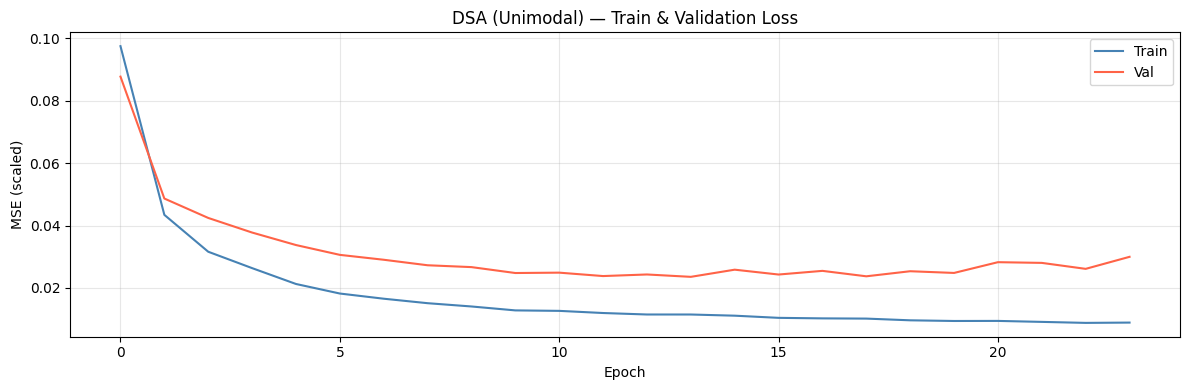

In [89]:
plt.figure(figsize=(12, 4))
plt.title('DSA (Unimodal) — Train & Validation Loss')
plt.plot(history['epoch'], history['train_loss'], label='Train', color='steelblue')
plt.plot(history['epoch'], history['val_loss'], label='Val', color='tomato')
plt.xlabel('Epoch')
plt.ylabel('MSE (scaled)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [90]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

test_preds, test_targets = [], []
with torch.no_grad():
    for batch in test_loader:

        num = batch[0].to(device) # Numerical Sequence (B, T, F)
        text_input = {k: v.to(device) for k, v in batch[1].items()} # Dict with input_ids & att_masks (B, T, L)
        targets = batch[2].to(device) # Targets (B, horizon)

        ## make preds 
        preds = model(text_input['input_ids'], text_input['attention_mask'], num) # (B, horizon)
        
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(targets.cpu().numpy())
        
test_preds = np.array(test_preds)
test_targets = np.array(test_targets)


In [91]:
inv_preds = target_scaler.inverse_transform(test_preds.reshape(-1,1)).reshape(-1,12)
inv_targets = target_scaler.inverse_transform(test_targets.reshape(-1,1)).reshape(-1,12)

In [92]:
mse_val = mean_squared_error(inv_targets.flatten(), inv_preds.flatten())
mae_val = mean_absolute_error(inv_targets.flatten(), inv_preds.flatten())
rmse_val = np.sqrt(mse_val)

print('=' * 60)
print(f'  DSA Unimodal    |  Test MSE : {mse_val:.4f}')
print(f'                  |  Test MAE : {mae_val:.4f}')
print(f'                  |  Test RMSE: {rmse_val:.4f}  (inverse-scaled)')
print(f'  DSA (mean/best) |  Test MSE : 1.120 ± 0.096 / 0.9749')
print('=' * 60)

  DSA Unimodal    |  Test MSE : 1.0852
                  |  Test MAE : 0.7397
                  |  Test RMSE: 1.0417  (inverse-scaled)
  DSA (mean/best) |  Test MSE : 1.120 ± 0.096 / 0.9749


In [93]:
# ── Per-sample errors for Diebold-Mariano (inverse-scaled, shape (N,)) ────────
per_sample_mse   = ((inv_preds - inv_targets) ** 2).mean(axis=1)   # (N,)
per_horizon_mse  = ((inv_preds - inv_targets) ** 2).mean(axis=0)   # (12,)

np.save(f'{LOG_DIR}/errors_DSA_unimodal.npy',  per_sample_mse)   # for DM test
np.save(f'{LOG_DIR}/horizon_DSA_unimodal.npy', per_horizon_mse)  # for horizon plot
np.save(f'{LOG_DIR}/preds_DSA_unimodal.npy',   inv_preds)        # full predictions
np.save(f'{LOG_DIR}/targets_DSA_unimodal.npy', inv_targets)      # ground truth

# ── Per-horizon MSE print ─────────────────────────────────────────────────────
print('\nPer-horizon MSE (weeks 1-12):')
for h, hmse in enumerate(per_horizon_mse, 1):
    print(f'  Week {h:2d}: {hmse:.4f}')


Per-horizon MSE (weeks 1-12):
  Week  1: 0.4128
  Week  2: 0.4717
  Week  3: 0.9376
  Week  4: 0.9667
  Week  5: 1.2603
  Week  6: 1.2677
  Week  7: 1.1208
  Week  8: 1.2654
  Week  9: 1.1523
  Week 10: 1.2526
  Week 11: 1.4711
  Week 12: 1.4433


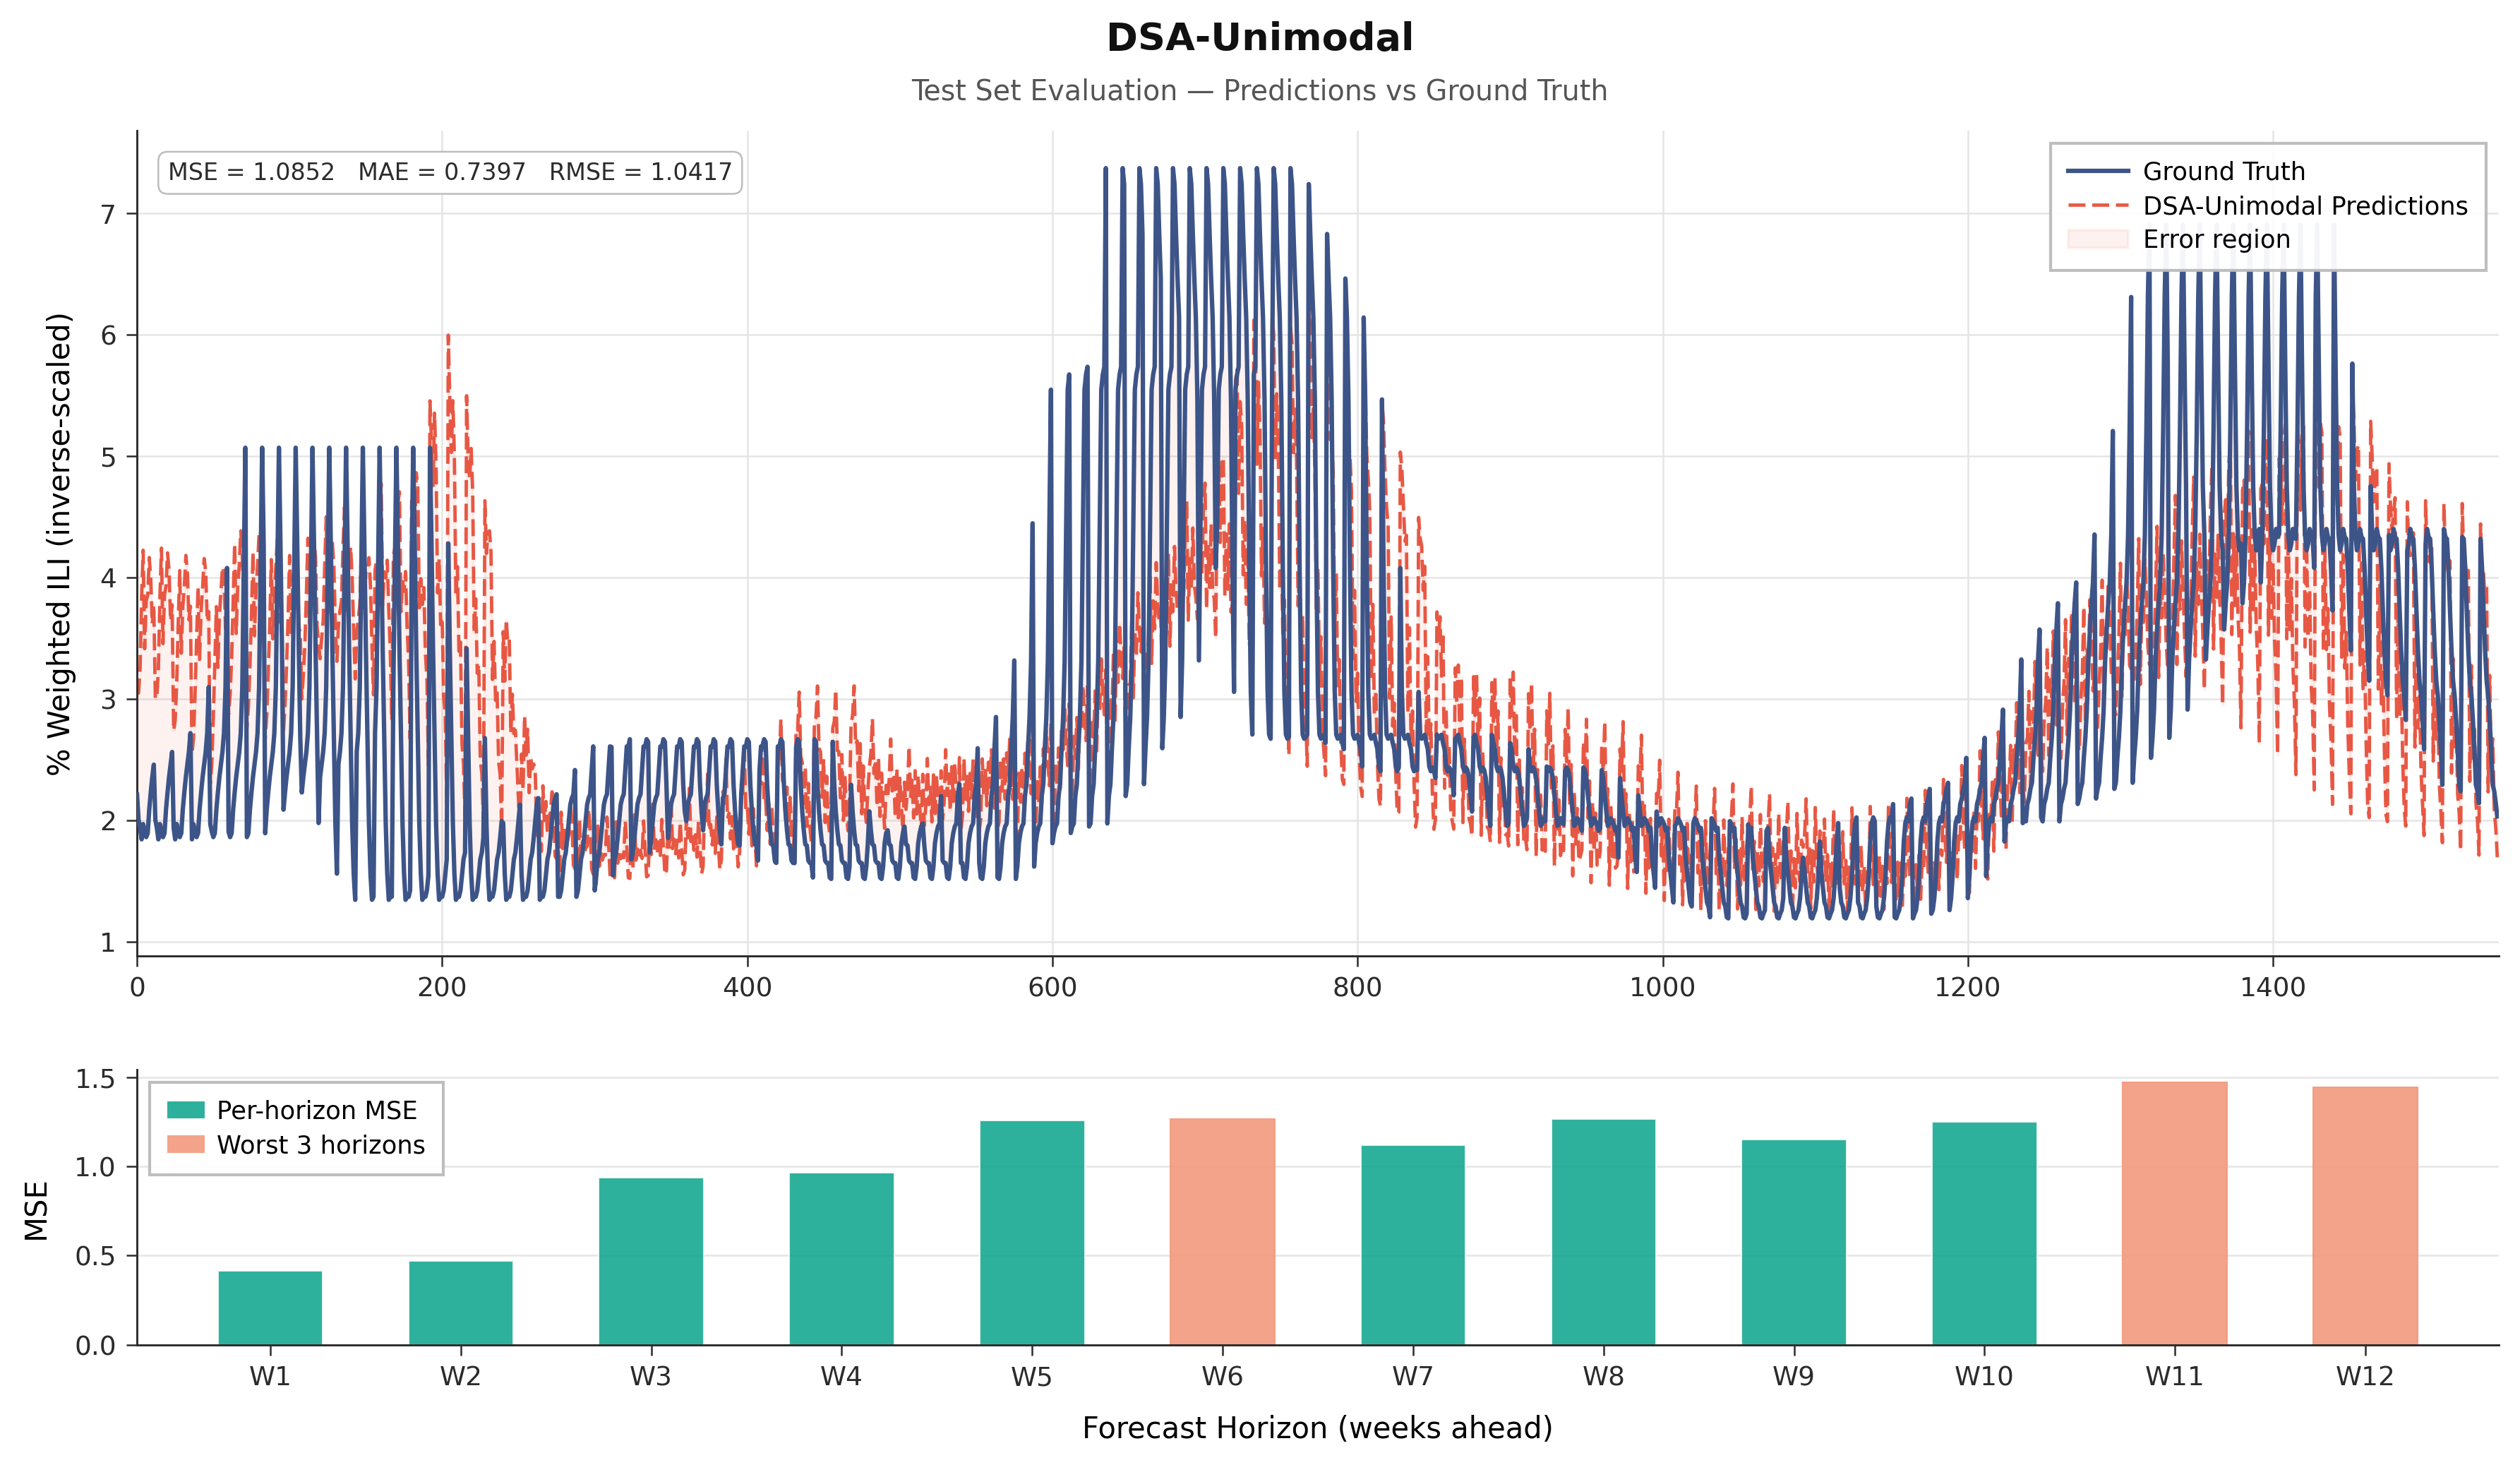

In [94]:
# ── NPG  palette ────────────────────────────────────
C_TRUTH  = '#3C5488'   # deep indigo   — ground truth
C_PRED   = '#E64B35'   # coral red     — predictions
C_FILL   = '#E64B35'   # error fill
C_BAR    = '#00A087'   # teal          — base bars
C_WORST  = '#F39B7F'   # soft salmon   — worst horizons
C_GRID   = '#E5E5E5'

mpl.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':          10,
    'axes.linewidth':     0.7,
    'axes.edgecolor':    '#2B2B2B',
    'axes.facecolor':    'white',
    'figure.facecolor':  'white',
    'xtick.major.width':  0.6, 'ytick.major.width':  0.6,
    'xtick.major.size':   3.5, 'ytick.major.size':   3.5,
    'xtick.direction':   'out', 'ytick.direction':   'out',
    'xtick.color':       '#2B2B2B', 'ytick.color':   '#2B2B2B',
    'legend.framealpha':  0.95, 'legend.edgecolor': '#BBBBBB',
    'legend.fancybox':    False,
})

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 6.5), dpi=300,
    gridspec_kw={'height_ratios': [3, 1]}
)

# ── Two-line title: bold model name + lighter subtitle ────────────────────────
fig.text(0.5, 1.03, 'DSA-Unimodal',
         ha='center', va='bottom',
         fontsize=13, fontweight='bold', color='#111111')
fig.text(0.5, 0.995, 'Test Set Evaluation — Predictions vs Ground Truth',
         ha='center', va='bottom',
         fontsize=9.5, fontweight='normal', color='#555555')

# ── Panel 1 ───────────────────────────────────────────────────────────────────
flat_targets = inv_targets.flatten()   # (N*12,)
flat_preds   = inv_preds.flatten()     # (N*12,)
timesteps    = np.arange(len(flat_targets))

ax1.plot(timesteps, flat_targets,
         color=C_TRUTH, linewidth=1.5, alpha=1.0,
         label='Ground Truth', zorder=3)
ax1.plot(timesteps, flat_preds,
         color=C_PRED, linewidth=1.15, linestyle='--',
         dashes=(5, 2), alpha=0.92,
         label='DSA-Unimodal Predictions', zorder=2)
ax1.fill_between(timesteps, flat_targets, flat_preds,
                 color=C_FILL, alpha=0.07, zorder=1, label='Error region')
ax1.set_ylabel('% Weighted ILI (inverse-scaled)', fontsize=10, labelpad=8)
ax1.set_xlim(0, len(flat_targets))
ax1.grid(True, color=C_GRID, linewidth=0.6, linestyle='-')
ax1.set_axisbelow(True)
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(axis='both', labelsize=9)
ax1.legend(loc='upper right', fontsize=8.5, handlelength=2.4,
           handletextpad=0.6, borderpad=0.7, labelspacing=0.4)
ax1.text(0.013, 0.963,
         f'MSE = {mse_val:.4f}   MAE = {mae_val:.4f}   RMSE = {rmse_val:.4f}',
         transform=ax1.transAxes, fontsize=8,
         verticalalignment='top', color='#2B2B2B',
         bbox=dict(boxstyle='round,pad=0.40', facecolor='white',
                   edgecolor='#BBBBBB', linewidth=0.6, alpha=0.97))

# ── Panel 2 ───────────────────────────────────────────────────────────────────
horizon_steps = np.arange(1, 13)
bars = ax2.bar(horizon_steps, per_horizon_mse,
               color=C_BAR, alpha=0.82, width=0.55,
               edgecolor='white', linewidth=0.5, zorder=2)
top3_idx = np.argsort(per_horizon_mse)[-3:]
for idx in top3_idx:
    bars[idx].set_color(C_WORST)
    bars[idx].set_alpha(0.92)
ax2.set_xlabel('Forecast Horizon (weeks ahead)', fontsize=10, labelpad=8)
ax2.set_ylabel('MSE', fontsize=10, labelpad=8)
ax2.set_xticks(horizon_steps)
ax2.set_xticklabels([f'W{h}' for h in horizon_steps], fontsize=8.5)
ax2.grid(axis='y', color=C_GRID, linewidth=0.6, linestyle='-')
ax2.set_axisbelow(True)
ax2.set_xlim(0.3, 12.7)
ax2.tick_params(axis='both', labelsize=9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(handles=[
    Patch(facecolor=C_BAR,   alpha=0.82, label='Per-horizon MSE'),
    Patch(facecolor=C_WORST, alpha=0.92, label='Worst 3 horizons'),
], fontsize=8.5, loc='upper left', handlelength=1.5,
   handletextpad=0.5, borderpad=0.7, labelspacing=0.4)

plt.tight_layout(h_pad=2.2)
plt.savefig(f'{LOG_DIR}/dsa_unimodal_test_evaluation.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()